---
title: "Mixture-CDF as a learnable bijector"
short_title: "03 · Learnable mixture-CDF"
subtitle: "Train the marginal end-to-end by maximum likelihood"
description: >
  The mixture-CDF marginal is a parametric bijector: train its weights, means,
  and scales end-to-end by maximum likelihood with optax. The forward map (and
  its log-det) differentiates by plain autodiff — which is all MLE needs;
  differentiating the root-find inverse is its own topic, covered in notebook 04.
---

(sec-nb-mt-03)=
# 03 — Mixture-CDF as a learnable bijector

Notebooks [01](01_kde_mixture_cdf.ipynb)–[02](02_spline_cdf.ipynb) *fit*
marginals by quantiles, EM, or plug-in rules. But the whole point of a
normalizing flow is that every layer is **differentiable in its parameters**, so
a deep stack can be trained *jointly* by gradient descent. This notebook treats
the mixture-CDF as that learnable layer and trains it end-to-end by maximum
likelihood.

**What you will see**

- The flow **MLE objective** — minimise the negative log-likelihood of the
  Gaussianized output.
- A `gauss_flows.MixtureGaussianCDF` marginal **trained end-to-end** with
  `optax` (loss curve + learned density), reaching the EM fit by gradient
  descent so it can train *jointly* inside a deep flow.

:::{note}
MLE training only differentiates the **forward** map (`transform` / log-det),
which is closed-form. Differentiating the **inverse** (the root-find, needed to
train through the *sampling* path) is a separate story — unrolling vs. one-step
vs. adjoint — told in
[notebook 04](04_inversion_strategies.ipynb) alongside the inversion methods.
:::

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats
import matplotlib.pyplot as plt
import numpy as np
import optax

import gauss_flows as gf
from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(13)

x = jnp.asarray(np.concatenate([rng.normal(-2.0, 0.5, 3000),
                                rng.normal(1.5, 0.8, 3000)])[:, None])

## 1. The maximum-likelihood objective

A marginal bijector $z = T_\theta(x)$ with base $\mathcal{N}(0,1)$ assigns each
point the log-density (change of variables, Part 0
[notebook 00](../00_foundations/00_change_of_variables.ipynb))

$$
\log p_\theta(x) = \log \phi\big(T_\theta(x)\big) + \log\big|T_\theta'(x)\big|,
$$

and training maximises the average $\log p_\theta$ — equivalently minimises the
**negative log-likelihood** $\mathcal{L}(\theta) = -\mathbb{E}_x[\log
p_\theta(x)]$. For `gauss_flows.MixtureGaussianCDF` the parameters $\theta$ are
the (unconstrained) mixture weights, means, and scales, and both terms above are
returned by `transform_and_log_det` — so $\mathcal{L}$ is a plain differentiable
function of $\theta$ that `optax` can descend.

In [2]:
def nll(bijector, xb):
    z, log_det = jax.vmap(bijector.transform_and_log_det)(xb)
    log_px = jnp.sum(jstats.norm.logpdf(z), axis=-1) + log_det
    return -jnp.mean(log_px)


# Start from a deliberately rough init, then learn the parameters end-to-end.
init = gf.MixtureGaussianCDF.from_data(x[::20], n_components=6)  # under-fit warm start
params, static = eqx.partition(init, eqx.is_inexact_array)
opt = optax.adam(1e-2)
opt_state = opt.init(params)


@eqx.filter_jit
def train_step(params, opt_state):
    loss, grads = eqx.filter_value_and_grad(
        lambda p: nll(eqx.combine(p, static), x))(params)
    updates, opt_state = opt.update(grads, opt_state)
    return eqx.apply_updates(params, updates), opt_state, loss


losses = []
for _ in range(200):
    params, opt_state, loss = train_step(params, opt_state)
    losses.append(float(loss))

trained = eqx.combine(params, static)
print(f"NLL: {losses[0]:.4f} (init) -> {losses[-1]:.4f} (trained)")

NLL: 1.7441 (init) -> 1.6490 (trained)


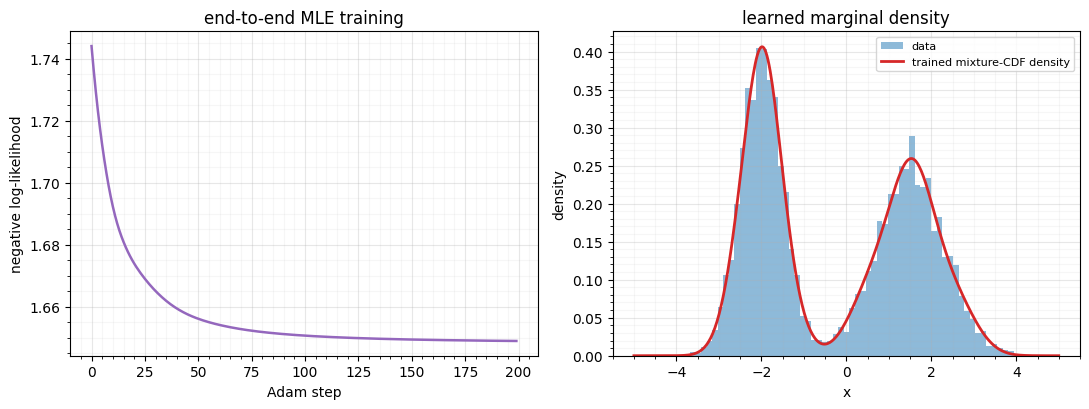

In [3]:
grid = jnp.linspace(-5, 5, 400)[:, None]
# density of the trained marginal: p(x) = phi(T(x)) * |T'(x)| = exp(logphi + logdet)
zt, ldt = jax.vmap(trained.transform_and_log_det)(grid)
dens_trained = np.exp(np.asarray(jstats.norm.logpdf(zt).sum(-1) + ldt))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(losses, color="tab:purple", lw=1.8)
axes[0].set(title="end-to-end MLE training", xlabel="Adam step",
            ylabel="negative log-likelihood")
style_ax(axes[0])

axes[1].hist(np.asarray(x)[:, 0], bins=60, density=True, color="tab:blue", alpha=0.5,
             label="data")
axes[1].plot(np.asarray(grid).ravel(), dens_trained, color="tab:red", lw=2,
             label="trained mixture-CDF density")
axes[1].set(title="learned marginal density", xlabel="x", ylabel="density")
axes[1].legend(fontsize=8); style_ax(axes[1])
fig.tight_layout()

The NLL falls and the learned density (red) locks onto the bimodal data — the
same fit EM gave in [notebook 01](01_kde_mixture_cdf.ipynb), but reached by
*gradient descent*. That difference is the whole point: because the layer is
differentiable in $\theta$, it drops into a deep flow and trains jointly with
every rotation and coupling around it, instead of being fit in isolation.

Training used only the **forward** gradient (`jax.grad` of `transform_and_log_det`,
all closed-form). The moment you instead train through the layer's *inverse* —
e.g. a sampling- or variational objective — you hit the root-find gradient
question, which [notebook 04](04_inversion_strategies.ipynb) answers.

## Recap

| piece | takeaway | in code |
|---|---|---|
| log-density | $\log\phi(T_\theta x) + \log\lvert T_\theta'\rvert$ | `transform_and_log_det` |
| MLE objective | minimise NLL of the Gaussianized output | `nll` |
| end-to-end training | gradient descent in $\theta$; stacks into deep flows | `optax` + `eqx.filter_value_and_grad` |
| forward gradient | closed form — all MLE needs | plain `jax.grad` |
| inverse gradient | unroll / one-step / adjoint | [notebook 04](04_inversion_strategies.ipynb) |

**Next up.** Training leaned on the closed-form forward map. The *inverse* is a
root-find, and [04 — Inversion strategies](04_inversion_strategies.ipynb)
covers it end to end: bisection vs. Newton, the safeguarded hybrid, how to
**differentiate** the inverse (and why unrolling can fail), and how to
vectorise it across a batch.